# E-Commerce Marketing & Sales Case Study

**Problem statement:** The e-commerce company aims to leverage data-driven insights to enhance
customer acquisition, retention, and revenue optimization. This notebook analyzes key business
trends across FY2019 transaction, customer, marketing, coupon, and tax data to answer ten
business questions and produce actionable, data-backed recommendations.

**How AI is used in this notebook:** After each business question is answered quantitatively,
a short narrative insight is generated by Google's Gemini model, grounded in the *actual computed
numbers* for that question (not generic text). The API key is never hardcoded. It is loaded from
a local, gitignored `.env` file, so nothing sensitive is exposed in this notebook or its PDF export.

# 1 · Imports & Configuration

Load the core stack for this analysis: **NumPy** for numerical/array operations, **pandas** for
tabular data manipulation, **Matplotlib** for figure-level plot control, and **Seaborn** (the only
charting library used for visualizations) for statistical graphics. We also fix a consistent plot
theme and pandas display options so every chart and table in the notebook renders consistently.

In [74]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 2 · Secure AI Setup (Gemini via Google AI Studio)

To turn computed metrics into business-ready narrative insights, we call Google's **Gemini**
model once per business question. The API key must never appear in this notebook or its PDF
export, so it is loaded at runtime from a local `.env` file (`E-commerce Case Study/.env`, listed
in `.gitignore`) using `python-dotenv`. Google's free tier caps each model at a small number of
requests per day, so `generate_insight()` walks down a chain of fallback models (each with its own
separate daily quota) whenever it hits a quota error, and only falls back to a plain text summary
if every model in the chain is exhausted or the key is missing, so the notebook stays fully
reproducible even under rate limits or without network access to the Gemini API.

In [75]:
from dotenv import load_dotenv
from google import genai

load_dotenv(Path.cwd() / ".env")

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GEMINI_MODEL_CHAIN = [
    model.strip()
    for model in os.getenv(
        "GEMINI_MODEL", "gemini-3.6-flash,gemini-3.5-flash-lite,gemini-flash-lite-latest,gemini-2.0-flash-lite"
    ).split(",")
]
_client = genai.Client(api_key=GOOGLE_API_KEY) if GOOGLE_API_KEY else None

def generate_insight(business_question, data_summary):
    fallback = (
        "**AI narrative unavailable**: set `GOOGLE_API_KEY` in `.env` to enable Gemini-generated "
        "insights. Review the computed metrics and chart above directly.\n\n"
        f"Computed summary:\n\n{data_summary}"
    )
    if _client is None:
        return fallback
    prompt = (
        "You are a senior e-commerce data analyst presenting findings to business stakeholders.\n"
        f"Business question: {business_question}\n\n"
        f"Computed data summary:\n{data_summary}\n\n"
        "Write a concise, business-ready insight (3-5 sentences) followed by 2-4 bullet-point "
        "recommendations, in markdown. Reference the specific numbers given. Do not restate the "
        "raw numbers as a table; weave them into the narrative. Use clear, well-punctuated "
        "sentences (commas, periods, colons, semicolons, and parentheses only). Do not use "
        "em dashes anywhere in the response."
    )
    last_error = None
    for model_name in GEMINI_MODEL_CHAIN:
        try:
            response = _client.models.generate_content(model=model_name, contents=prompt)
            return response.text
        except Exception as exc:
            last_error = exc
            continue
    return fallback + f"\n\n_(Gemini call failed on all models in the fallback chain: {last_error})_"

# 3 · Loading the Raw Datasets

Five source files make up this case study: transaction-level online sales, customer demographics,
monthly discount coupons by category, day-wise marketing spend, and category-wise GST rates. Load
each into its own DataFrame as a first step before any cleaning or joining.

In [76]:
DATA_DIR = Path("../Datasets/Case_Study")

online = pd.read_csv(DATA_DIR / "Online_Sales.csv")
customers = pd.read_excel(DATA_DIR / "CustomersData.xlsx")
coupon = pd.read_csv(DATA_DIR / "Discount_Coupon.csv")
marketing = pd.read_csv(DATA_DIR / "Marketing_Spend.csv")
tax = pd.read_excel(DATA_DIR / "Tax_amount.xlsx")

print(f"Online_Sales     : {online.shape}")
print(f"CustomersData    : {customers.shape}")
print(f"Discount_Coupon  : {coupon.shape}")
print(f"Marketing_Spend  : {marketing.shape}")
print(f"Tax_amount       : {tax.shape}")

Online_Sales     : (52924, 10)
CustomersData    : (1468, 4)
Discount_Coupon  : (204, 4)
Marketing_Spend  : (365, 3)
Tax_amount       : (20, 2)


## 3.1 · Structural Inspection

Before cleaning, check each dataset's data types, missing values, and duplicate rows. This
confirms whether type conversions (e.g. `Transaction_Date` is currently text) or null-handling are
required before the datasets can be safely merged and aggregated.

In [77]:
def inspect(name, df):
    return pd.Series({
        "rows": df.shape[0],
        "cols": df.shape[1],
        "nulls": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }, name=name)

inspection = pd.DataFrame([
    inspect("Online_Sales", online),
    inspect("CustomersData", customers),
    inspect("Discount_Coupon", coupon),
    inspect("Marketing_Spend", marketing),
    inspect("Tax_amount", tax),
])
inspection

,rows,cols,nulls,duplicate_rows
Online_Sales,52924,10,0,0
CustomersData,1468,4,0,0
Discount_Coupon,204,4,0,0
Marketing_Spend,365,3,0,0
Tax_amount,20,2,0,0


## 3.2 · Data Quality Checks & Known Quirks

Two subtler checks matter before merging: whether category names line up consistently across
`Online_Sales`, `Discount_Coupon`, and `Tax_amount`, and whether every "Used" coupon actually has a
matching discount definition for that month/category. Both are verified explicitly here rather than
assumed, and any mismatch is deliberately defaulted to a 0% discount in the next section.

In [78]:
online["Transaction_Date"] = pd.to_datetime(online["Transaction_Date"], format="%m/%d/%Y")
online["Month_Abbr"] = online["Transaction_Date"].dt.strftime("%b")

online_categories = set(online["Product_Category"].unique())
coupon_categories = set(coupon["Product_Category"].unique())
tax_categories = set(tax["Product_Category"].unique())

print("Categories with no coupon program at all:", online_categories - coupon_categories)
print("Coupon categories absent from sales data :", coupon_categories - online_categories)
print("Categories missing a GST rate            :", online_categories - tax_categories)

trial_merge = online.merge(
    coupon, left_on=["Month_Abbr", "Product_Category"], right_on=["Month", "Product_Category"], how="left"
)
unmatched_used = trial_merge[(trial_merge["Coupon_Status"] == "Used") & (trial_merge["Discount_pct"].isnull())]
print(f"\n'Used' coupon rows with no matching coupon definition: {len(unmatched_used)}")
print(unmatched_used["Product_Category"].value_counts())

Categories with no coupon program at all: {'More Bags', 'Fun', 'Backpacks', 'Google'}
Coupon categories absent from sales data : {'Notebooks'}
Categories missing a GST rate            : set()

'Used' coupon rows with no matching coupon definition: 126
Product_Category
Fun          52
Google       29
Backpacks    27
More Bags    18
Name: count, dtype: int64


## 3.3 · Date Parsing & Feature Engineering

With category alignment verified, extract the calendar features needed throughout the analysis:
month period, month name, and day of week for sales, plus a combined spend column for marketing.
This lets every downstream question group by time consistently.

In [79]:
online["Month_Period"] = online["Transaction_Date"].dt.to_period("M")
online["Month_Name"] = online["Transaction_Date"].dt.strftime("%b")
online["Day_Of_Week"] = online["Transaction_Date"].dt.day_name()

marketing["Date"] = pd.to_datetime(marketing["Date"], format="%m/%d/%Y")
marketing["Total_Spend"] = marketing["Offline_Spend"] + marketing["Online_Spend"]

online[["Transaction_Date", "Month_Period", "Month_Name", "Day_Of_Week"]].head()

,Transaction_Date,Month_Period,Month_Name,Day_Of_Week
0,2019-01-01,2019-01,Jan,Tuesday
1,2019-01-01,2019-01,Jan,Tuesday
2,2019-01-01,2019-01,Jan,Tuesday
3,2019-01-01,2019-01,Jan,Tuesday
4,2019-01-01,2019-01,Jan,Tuesday


# 4 · Building the Master Transaction Table

The approach document defines revenue as **Invoice Value**:

`Invoice_Value = (Quantity × Avg_Price) × (1 − Discount_pct) × (1 + GST) + Delivery_Charges`

Building it requires three left-joins onto `Online_Sales`: coupon discounts (only where a coupon
was actually **Used**), category GST rates, and customer demographics. Each join is applied step by
step so intermediate correctness can be checked before the final formula is computed.

In [80]:
master = online.merge(
    coupon, left_on=["Month_Abbr", "Product_Category"], right_on=["Month", "Product_Category"], how="left"
)
master["Discount_pct"] = np.where(master["Coupon_Status"] == "Used", master["Discount_pct"].fillna(0), 0)

master = master.merge(tax, on="Product_Category", how="left")
master = master.merge(customers, on="CustomerID", how="left")

master["Invoice_Value"] = (
    (master["Quantity"] * master["Avg_Price"]) * (1 - master["Discount_pct"] / 100) * (1 + master["GST"])
    + master["Delivery_Charges"]
)

master = master.drop(columns=["Month", "Coupon_Code"])
print(f"Master table shape: {master.shape}")
master[["CustomerID", "Transaction_Date", "Product_Category", "Quantity", "Avg_Price",
        "Discount_pct", "GST", "Delivery_Charges", "Invoice_Value"]].head()

Master table shape: (52924, 20)


,CustomerID,Transaction_Date,Product_Category,Quantity,Avg_Price,Discount_pct,GST,Delivery_Charges,Invoice_Value
0,17850,2019-01-01,Nest-USA,1,153.71,10.00,0.10,6.50,158.67
1,17850,2019-01-01,Nest-USA,1,153.71,10.00,0.10,6.50,158.67
2,17850,2019-01-01,Office,1,2.05,10.00,0.10,6.50,8.53
3,17850,2019-01-01,Apparel,5,17.53,0.00,0.18,6.50,109.93
4,17850,2019-01-01,Bags,1,16.50,10.00,0.18,6.50,24.02


## 4.1 · Sanity Check on the Master Table

Confirm the merge introduced no unexpected nulls and that `Invoice_Value` is sensible (strictly
positive, no extreme outliers from a broken join) before it becomes the revenue figure used in
every business question that follows.

In [81]:
null_summary = master.isnull().sum()
print("Columns with nulls after merge:")
print(null_summary[null_summary > 0] if null_summary.any() else "None")
print()
master["Invoice_Value"].describe()

Columns with nulls after merge:
None



count   52,924.00
mean       101.98
std        172.37
min          4.60
25%         20.16
50%         45.64
75%        137.40
max      8,979.27
Name: Invoice_Value, dtype: float64

# 5 · Dataset Overview at a Glance

Before answering the ten business questions individually, get oriented with the shape of a full
year of business: how revenue moves month to month, and which product categories and locations
dominate the customer base. This context frames the more targeted analyses that follow.

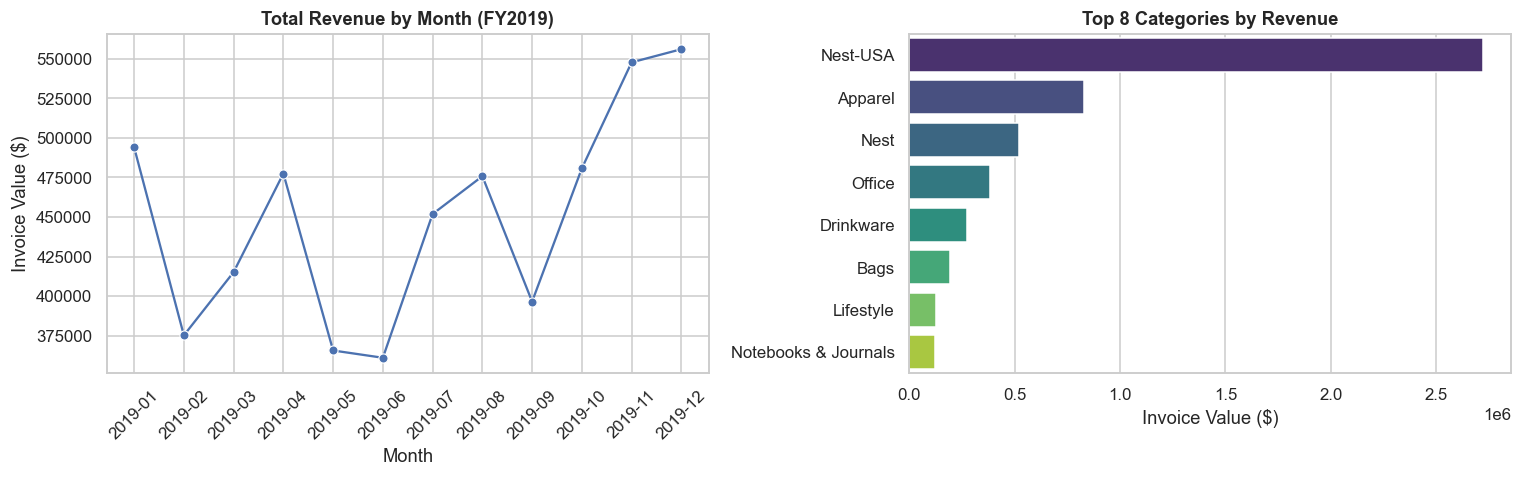

FY2019 total revenue: $5,397,359
Total transactions  : 25,061
Unique customers    : 1,468


In [82]:
monthly_revenue = master.groupby("Month_Period")["Invoice_Value"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.lineplot(x=monthly_revenue.index.astype(str), y=monthly_revenue.values, marker="o", ax=axes[0])
axes[0].set_title("Total Revenue by Month (FY2019)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Invoice Value ($)")
axes[0].tick_params(axis="x", rotation=45)

top_categories = master.groupby("Product_Category")["Invoice_Value"].sum().sort_values(ascending=False).head(8)
sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[1], palette="viridis")
axes[1].set_title("Top 8 Categories by Revenue")
axes[1].set_xlabel("Invoice Value ($)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"FY2019 total revenue: ${master['Invoice_Value'].sum():,.0f}")
print(f"Total transactions  : {master['Transaction_ID'].nunique():,}")
print(f"Unique customers    : {master['CustomerID'].nunique():,}")

## 5.1 · Distribution Analysis: Histograms and KDEs

Summary statistics alone hide shape. Before slicing revenue by month, product, or segment, look at
how the core numeric fields are actually distributed: `Invoice_Value`, `Quantity` per line item, and
`Delivery_Charges`. A histogram with a kernel density estimate (KDE) overlay shows both the discrete
shape and the smoothed trend in one view, and immediately reveals the right-skew typical of retail
transaction values.

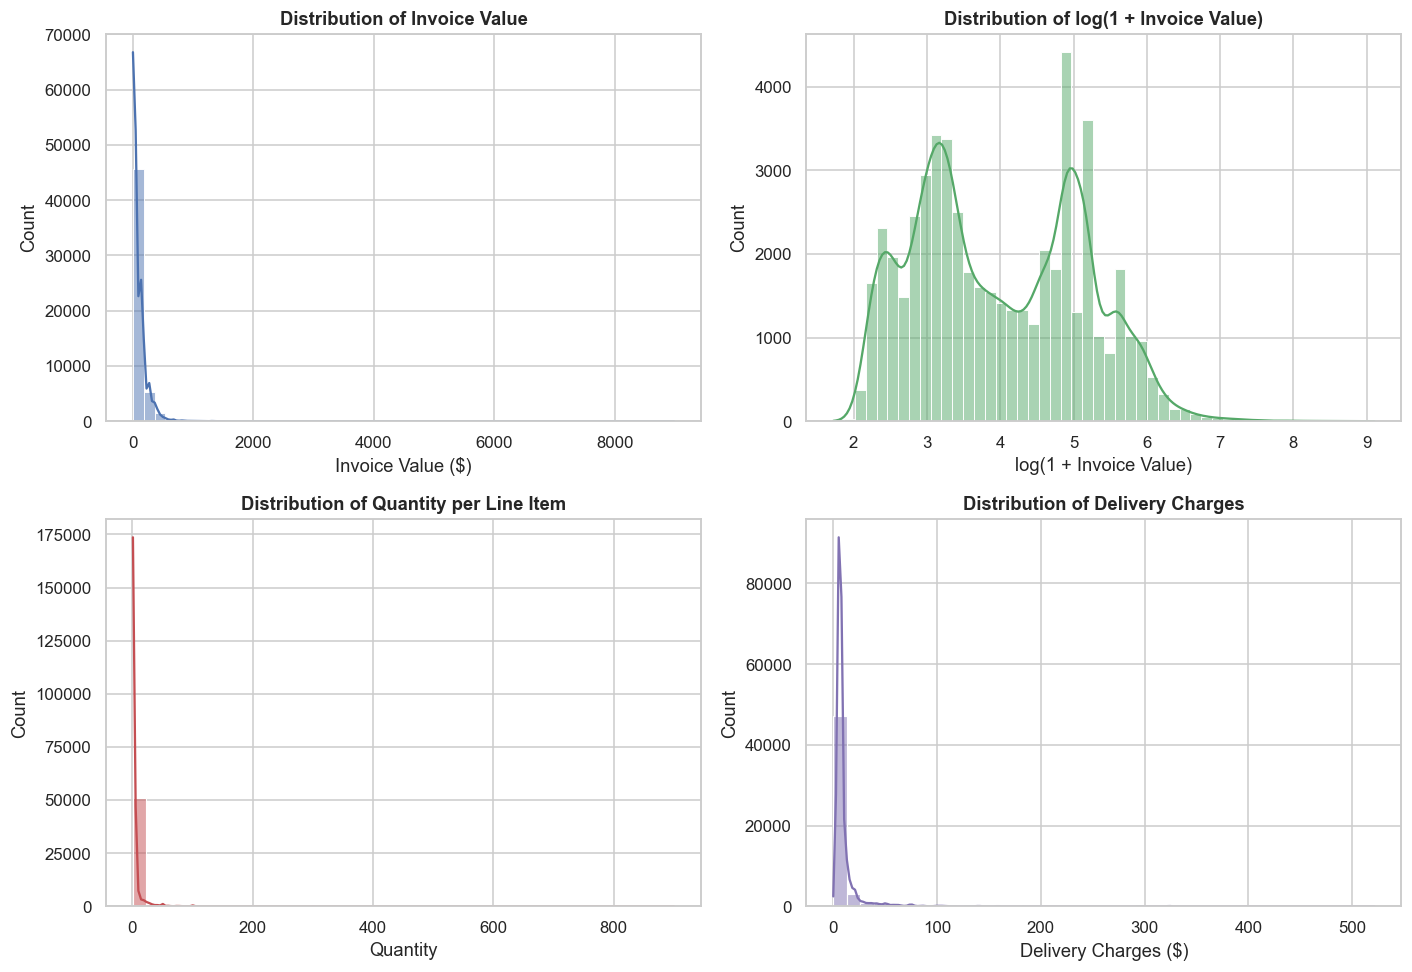

Invoice_Value skewness: 16.28
Quantity skewness     : 19.03


In [83]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(master["Invoice_Value"], kde=True, bins=50, ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("Distribution of Invoice Value")
axes[0, 0].set_xlabel("Invoice Value ($)")

sns.histplot(np.log1p(master["Invoice_Value"]), kde=True, bins=50, ax=axes[0, 1], color="#55a868")
axes[0, 1].set_title("Distribution of log(1 + Invoice Value)")
axes[0, 1].set_xlabel("log(1 + Invoice Value)")

sns.histplot(master["Quantity"], kde=True, bins=40, ax=axes[1, 0], color="#c44e52")
axes[1, 0].set_title("Distribution of Quantity per Line Item")
axes[1, 0].set_xlabel("Quantity")

sns.histplot(master["Delivery_Charges"], kde=True, bins=40, ax=axes[1, 1], color="#8172b2")
axes[1, 1].set_title("Distribution of Delivery Charges")
axes[1, 1].set_xlabel("Delivery Charges ($)")

plt.tight_layout()
plt.show()

print(f"Invoice_Value skewness: {master['Invoice_Value'].skew():.2f}")
print(f"Quantity skewness     : {master['Quantity'].skew():.2f}")

## 5.2 · Outlier Detection and Category Spread: Boxplots

Boxplots make outliers and spread explicit in a way a single mean cannot. Check `Invoice_Value` for
extreme outliers across the full dataset, then compare its spread across the top categories, since a
wide interquartile range in a category signals inconsistent order sizes that a single average would
mask.

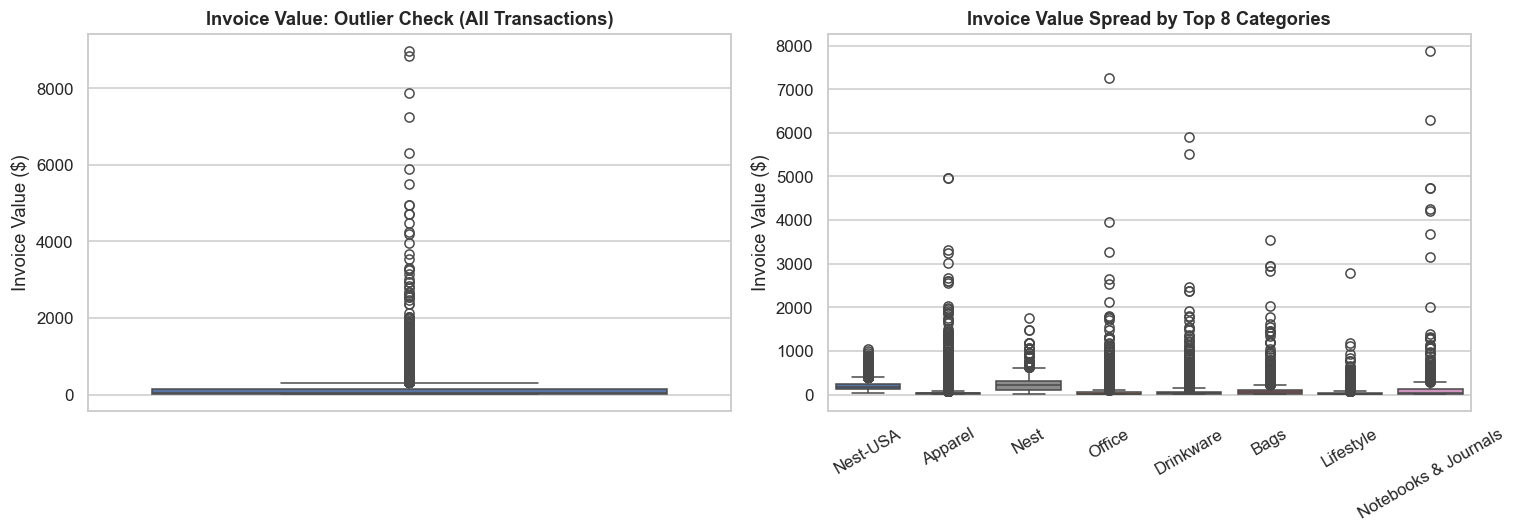

99th percentile Invoice Value: $580.16
Transactions above the 99th percentile: 530


In [84]:
top8_categories = master.groupby("Product_Category")["Invoice_Value"].sum().sort_values(ascending=False).head(8).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=master["Invoice_Value"], ax=axes[0], color="#4c72b0")
axes[0].set_title("Invoice Value: Outlier Check (All Transactions)")
axes[0].set_ylabel("Invoice Value ($)")

sns.boxplot(data=master[master["Product_Category"].isin(top8_categories)], x="Product_Category",
            y="Invoice_Value", order=top8_categories, hue="Product_Category", legend=False, ax=axes[1])
axes[1].set_title("Invoice Value Spread by Top 8 Categories")
axes[1].set_xlabel("")
axes[1].set_ylabel("Invoice Value ($)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

q99 = master["Invoice_Value"].quantile(0.99)
print(f"99th percentile Invoice Value: ${q99:,.2f}")
print(f"Transactions above the 99th percentile: {(master['Invoice_Value'] > q99).sum()}")

# 6 · Q1: Monthly Customer Acquisition Trend

**Business question:** Identify the months with the highest and lowest acquisition count. What
strategies could be implemented to address the fluctuations and ensure consistent growth throughout
the year?

Acquisition means a customer's **first-ever purchase**. Group `Online_Sales` by `CustomerID`, take
the earliest `Transaction_Date` per customer, extract its month, and count how many customers were
first acquired in each month.

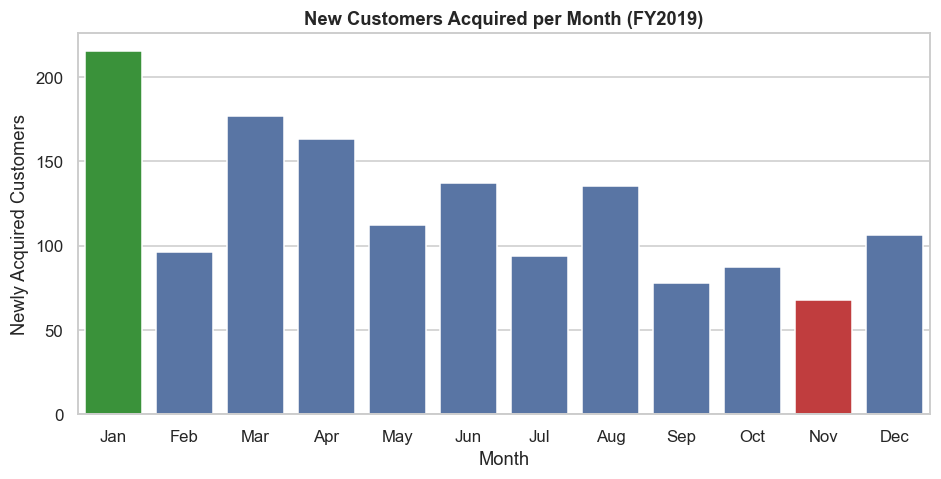

Highest acquisition month: Jan (215 new customers)
Lowest acquisition month : Nov (68 new customers)


In [85]:
first_purchase = online.groupby("CustomerID")["Transaction_Date"].min().rename("First_Purchase_Date").reset_index()
first_purchase["Acquisition_Month"] = first_purchase["First_Purchase_Date"].dt.strftime("%b")
first_purchase["Acquisition_Period"] = first_purchase["First_Purchase_Date"].dt.to_period("M")

acquisition_counts = first_purchase["Acquisition_Month"].value_counts().reindex(MONTH_ORDER)
peak_month, trough_month = acquisition_counts.idxmax(), acquisition_counts.idxmin()
bar_colors = ["#2ca02c" if m == peak_month else "#d62728" if m == trough_month else "#4c72b0" for m in MONTH_ORDER]

plt.figure(figsize=(10, 4.5))
sns.barplot(x=acquisition_counts.index, y=acquisition_counts.values, hue=acquisition_counts.index,
            palette=bar_colors, legend=False)
plt.title("New Customers Acquired per Month (FY2019)")
plt.xlabel("Month")
plt.ylabel("Newly Acquired Customers")
plt.show()

print(f"Highest acquisition month: {peak_month} ({acquisition_counts.max()} new customers)")
print(f"Lowest acquisition month : {trough_month} ({acquisition_counts.min()} new customers)")

### Does Acquisition Actually Track Marketing Spend?

`Marketing_Spend.csv` was loaded during data preparation but not yet used. Rather than assume the
acquisition swings above are driven by spend, check it directly: aggregate the day-wise offline and
online spend into monthly totals, plot it against the monthly acquisition count on a shared time
axis, and compute the Pearson correlation between the two series. A weak correlation would mean the
acquisition dips are not simply an underspending problem, and a different lever (channel mix,
creative, seasonality) needs attention instead.

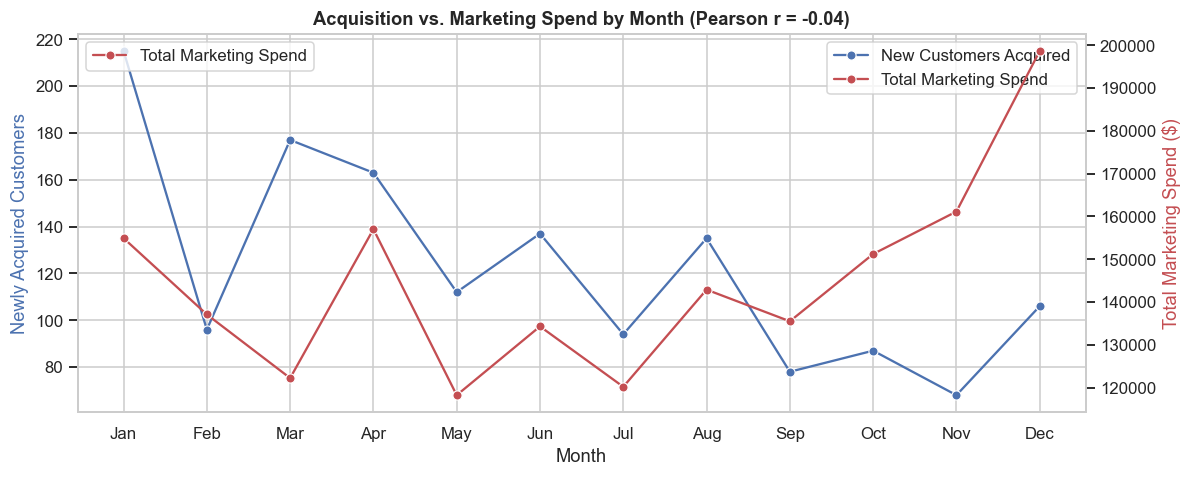

Correlation between monthly marketing spend and monthly acquisition count: -0.04


,Acquisition_Count,Total_Spend
Jan,215,"154,928.95"
Feb,96,"137,107.92"
Mar,177,"122,250.09"
Apr,163,"157,026.83"
May,112,"118,259.64"
Jun,137,"134,318.14"
Jul,94,"120,217.85"
Aug,135,"142,904.15"
Sep,78,"135,514.54"
Oct,87,"151,224.65"


In [86]:
monthly_spend = marketing.groupby(marketing["Date"].dt.strftime("%b"))["Total_Spend"].sum().reindex(MONTH_ORDER)
spend_vs_acquisition = pd.DataFrame({"Acquisition_Count": acquisition_counts, "Total_Spend": monthly_spend})
spend_acquisition_corr = spend_vs_acquisition["Acquisition_Count"].corr(spend_vs_acquisition["Total_Spend"])

fig, ax1 = plt.subplots(figsize=(11, 4.5))
sns.lineplot(x=MONTH_ORDER, y=spend_vs_acquisition["Acquisition_Count"], marker="o", ax=ax1,
             color="#4c72b0", label="New Customers Acquired")
ax1.set_xlabel("Month")
ax1.set_ylabel("Newly Acquired Customers", color="#4c72b0")

ax2 = ax1.twinx()
sns.lineplot(x=MONTH_ORDER, y=spend_vs_acquisition["Total_Spend"], marker="o", ax=ax2,
             color="#c44e52", label="Total Marketing Spend")
ax2.set_ylabel("Total Marketing Spend ($)", color="#c44e52")
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.set_title(f"Acquisition vs. Marketing Spend by Month (Pearson r = {spend_acquisition_corr:.2f})")

plt.tight_layout()
plt.show()

print(f"Correlation between monthly marketing spend and monthly acquisition count: {spend_acquisition_corr:.2f}")
spend_vs_acquisition

In [87]:
q1_summary = (
    f"Monthly new-customer counts across FY2019: {acquisition_counts.to_dict()}. "
    f"Highest acquisition month: {peak_month} with {acquisition_counts.max()} new customers. "
    f"Lowest acquisition month: {trough_month} with {acquisition_counts.min()} new customers. "
    f"Monthly marketing spend ($): {monthly_spend.round(0).to_dict()}. "
    f"Pearson correlation between monthly marketing spend and monthly acquisition count: "
    f"{spend_acquisition_corr:.2f} (near zero or negative means acquisition dips are not simply "
    f"an underspending problem)."
)
display(Markdown(generate_insight(
    "Identify the months with the highest and lowest acquisition count. What strategies could be "
    "implemented to address the fluctuations and ensure consistent growth throughout the year?",
    q1_summary,
)))

An analysis of FY2019 customer acquisition reveals extreme seasonality, peaking in January at 215 new customers and bottoming out in November at just 68. Intriguingly, the data shows a near-zero correlation (-0.04) between monthly marketing spend and acquisition counts, evidenced by November receiving the second-highest spend ($161,145) yet yielding the lowest customer return. This disconnect indicates that current campaign timing and messaging are misaligned with consumer intent, meaning simply pouring more money into underperforming months will not solve the acquisition slump.

* **Reallocate budget based on efficiency:** Shift capital away from traditionally low-converting periods, such as November, and reinvest those funds into high-intent acquisition windows like January or targeted retention campaigns.
* **Diagnose November's conversion bottleneck:** Investigate why heavy November marketing spend failed to capture customers, examining whether promotional offers, landing page friction, or competitive pressures undermined the campaigns.
* **Develop counter-cyclical retention and acquisition hooks:** Introduce mid-year loyalty incentives, exclusive product drops, or referral bonuses during historical troughs (such as September and November) to smooth out monthly volatility and stabilize baseline traffic.

# 7 · Q2: Customer Behaviour in High-Retention Months

**Business question:** Analyze customer behavior during high-retention months and suggest ways to
replicate this success throughout the year.

First classify every transaction as coming from a **New** customer (their first purchase month) or
an **Existing** one, at the month level. The monthly retention rate is the share of active
customers that month who were already existing. January is structurally excluded from the
high/low comparison: with no prior history in the dataset, 100% of its customers are "new" by
definition. We then compare average order value, coupon redemption, and category mix between the
highest- and lowest-retention months.

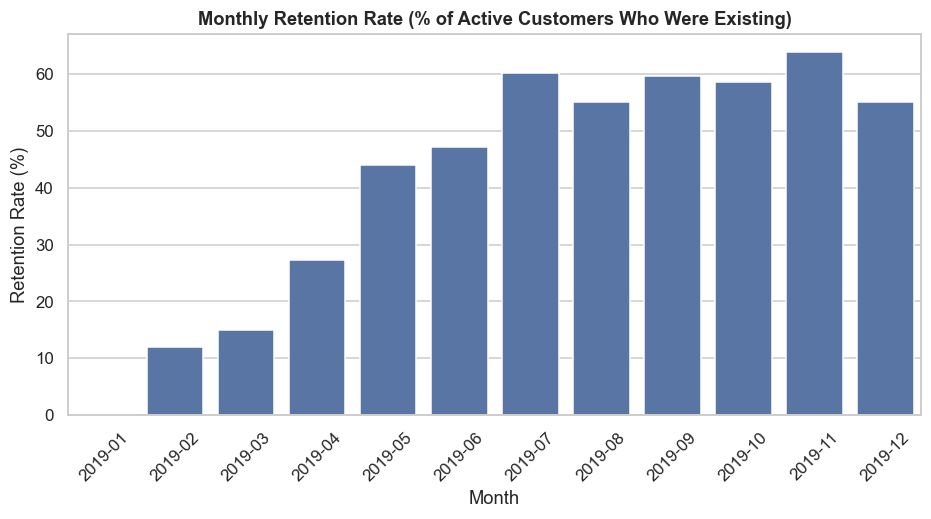

Top 3 retention months:
              Avg_Order_Value  Coupon_Usage_Rate  Retention_Rate
Month_Period                                                    
2019-11                138.30               0.34            0.64
2019-07                 86.06               0.33            0.60
2019-09                 92.47               0.35            0.60

Bottom 3 retention months (excluding January):
              Avg_Order_Value  Coupon_Usage_Rate  Retention_Rate
Month_Period                                                    
2019-01                121.61               0.34            0.00
2019-02                114.24               0.33            0.12
2019-03                 95.53               0.34            0.15


In [88]:
master = master.merge(first_purchase[["CustomerID", "Acquisition_Period"]], on="CustomerID", how="left")
master["Is_New_This_Month"] = master["Month_Period"] == master["Acquisition_Period"]
master["Customer_Type"] = np.where(master["Is_New_This_Month"], "New", "Existing")

monthly_customer_mix = master.groupby(["Month_Period", "Customer_Type"])["CustomerID"].nunique().unstack(fill_value=0)
monthly_customer_mix["Retention_Rate"] = monthly_customer_mix["Existing"] / (
    monthly_customer_mix["Existing"] + monthly_customer_mix["New"]
)

monthly_behaviour = master.groupby("Month_Period").agg(
    Avg_Order_Value=("Invoice_Value", "mean"),
    Coupon_Usage_Rate=("Coupon_Status", lambda s: (s == "Used").mean()),
).join(monthly_customer_mix["Retention_Rate"])

plt.figure(figsize=(10, 4.5))
sns.barplot(x=monthly_behaviour.index.astype(str), y=monthly_behaviour["Retention_Rate"] * 100,
            color="#4c72b0")
plt.title("Monthly Retention Rate (% of Active Customers Who Were Existing)")
plt.xlabel("Month")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=45)
plt.show()

comparable_months = monthly_behaviour.dropna(subset=["Retention_Rate"])
high_retention = comparable_months.nlargest(3, "Retention_Rate")
low_retention = comparable_months.nsmallest(3, "Retention_Rate")

print("Top 3 retention months:")
print(high_retention)
print("\nBottom 3 retention months (excluding January):")
print(low_retention)

### Deeper Look: Order-Value Distribution, Not Just the Average

A retention-rate ranking only compares month-level averages. To understand *behavior* rather than a
single number, overlay the full order-value distribution for the highest- and lowest-retention
months using a KDE plot: if high-retention months skew toward larger, more consistent orders, that
is a very different story from a low-retention month with a few large outliers propping up the mean.

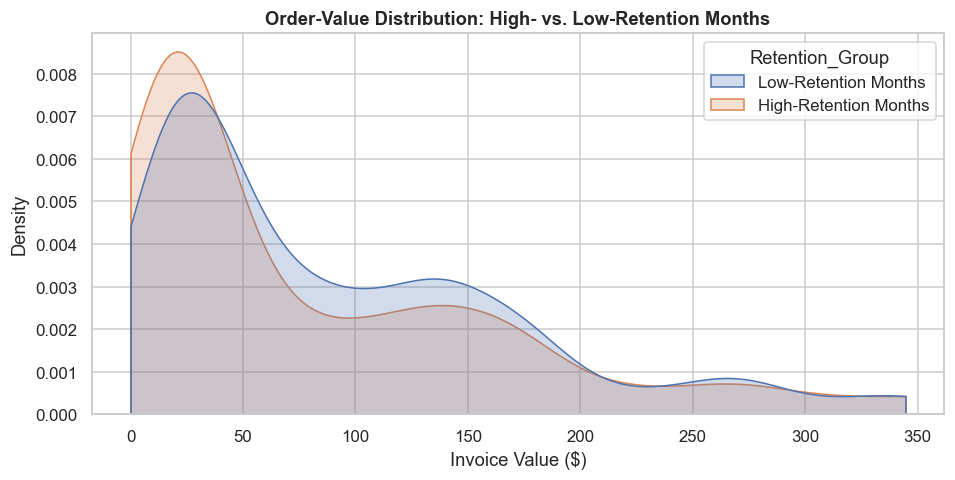

,mean,50%,std
Retention_Group,,,
High-Retention Months,103.42,42.99,154.95
Low-Retention Months,109.84,67.64,141.12


In [89]:
behaviour_sample = master[master["Month_Period"].isin(high_retention.index.tolist() + low_retention.index.tolist())].copy()
behaviour_sample["Retention_Group"] = np.where(
    behaviour_sample["Month_Period"].isin(high_retention.index), "High-Retention Months", "Low-Retention Months"
)

plt.figure(figsize=(10, 4.5))
sns.kdeplot(data=behaviour_sample, x="Invoice_Value", hue="Retention_Group", fill=True,
            common_norm=False, clip=(0, behaviour_sample["Invoice_Value"].quantile(0.95)))
plt.title("Order-Value Distribution: High- vs. Low-Retention Months")
plt.xlabel("Invoice Value ($)")
plt.show()

behaviour_sample.groupby("Retention_Group")["Invoice_Value"].describe()[["mean", "50%", "std"]]

In [90]:
q2_summary = (
    f"Top 3 retention months: {high_retention[['Retention_Rate','Avg_Order_Value','Coupon_Usage_Rate']].round(3).to_dict('index')}. "
    f"Bottom 3 retention months: {low_retention[['Retention_Rate','Avg_Order_Value','Coupon_Usage_Rate']].round(3).to_dict('index')}."
)
display(Markdown(generate_insight(
    "Analyze customer behavior during high-retention months and suggest ways to replicate this "
    "success throughout the year.",
    q2_summary,
)))

Customer retention in 2019 peaked during November, July, and September, achieving high retention rates of 0.638, 0.602, and 0.596, respectively. Notably, November also drove a peak average order value of 138.295, whereas July and September maintained moderate order values of 86.056 and 92.47. Across these top months, coupon usage remained remarkably consistent at approximately 0.340, indicating that promotional incentives are a stable baseline driver rather than the sole catalyst for retention spikes. Conversely, early-year retention dropped severely to 0.0 in January, 0.119 in February, and 0.149 in March, despite similar coupon usage rates near 0.337.

* Implement targeted re-engagement campaigns in low-performing early-year months (such as January through March) to bridge the steep retention gap compared to the peak periods.
* Replicate the high-value bundling strategies observed in November (AOV of 138.295) during standard months to elevate overall basket sizes.
* Maintain a steady coupon usage rate around 0.340 across all seasonal promotions, as this threshold aligns closely with periods of peak customer loyalty.

# 8 · Q3: New vs. Existing Customer Revenue Trend

**Business question:** Compare the revenue generated by new and existing customers month-over-month.
What does this trend suggest about the balance between acquisition and retention efforts?

Reusing the `Customer_Type` flag from Q2, sum `Invoice_Value` by month and customer type to see how
the acquisition/retention revenue mix shifts across the year.

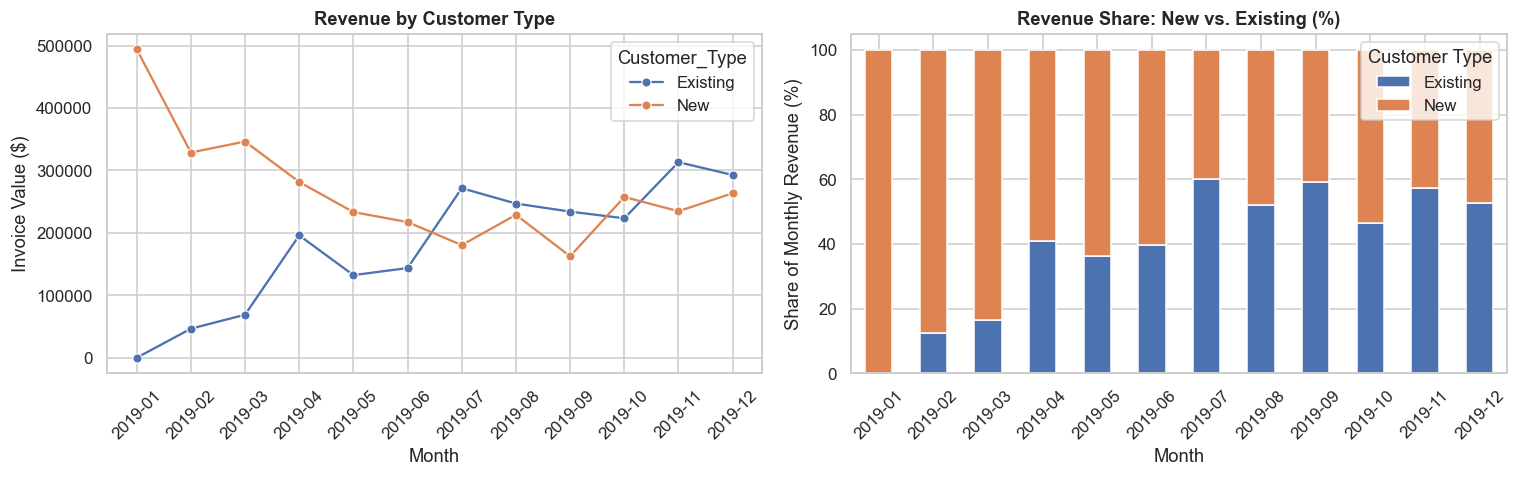

Customer_Type,Existing,New
Month_Period,,
2019-01,0.00,"494,090.55"
2019-02,"46,524.59","328,637.45"
2019-03,"68,930.24","346,227.55"
2019-04,"195,985.89","281,512.70"
2019-05,"132,338.75","233,257.28"
2019-06,"143,665.67","217,334.51"
2019-07,"271,515.73","180,362.68"
2019-08,"246,913.10","228,883.78"
2019-09,"234,031.96","162,478.53"


In [91]:
monthly_type_revenue = master.groupby(["Month_Period", "Customer_Type"])["Invoice_Value"].sum().unstack(fill_value=0)
monthly_type_share = monthly_type_revenue.div(monthly_type_revenue.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_df = monthly_type_revenue.reset_index().melt(id_vars="Month_Period", var_name="Customer_Type", value_name="Revenue")
plot_df["Month_Period"] = plot_df["Month_Period"].astype(str)
sns.lineplot(data=plot_df, x="Month_Period", y="Revenue", hue="Customer_Type", marker="o", ax=axes[0])
axes[0].set_title("Revenue by Customer Type")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Invoice Value ($)")
axes[0].tick_params(axis="x", rotation=45)

monthly_type_share.plot(kind="bar", stacked=True, ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set_title("Revenue Share: New vs. Existing (%)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Share of Monthly Revenue (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Customer Type")

plt.tight_layout()
plt.show()

monthly_type_revenue

In [92]:
q3_summary = (
    f"Monthly revenue by customer type ($): {monthly_type_revenue.round(0).astype(int).to_dict('index')}. "
    f"Existing-customer revenue share (%) by month: {monthly_type_share['Existing'].round(1).to_dict()}."
)
display(Markdown(generate_insight(
    "Compare the revenue generated by new and existing customers month-over-month. What does this "
    "trend suggest about the balance between acquisition and retention efforts?",
    q3_summary,
)))

In 2019, our revenue dynamics shifted significantly from an acquisition-heavy model to a balanced engine driven increasingly by retention. At the start of the year in January, new customers accounted for all revenue ($494,091), with existing customer revenue at zero. By July, however, retention efforts successfully flipped this balance, as existing customers drove the majority of sales at 60.1% ($271,516). This maturation continued through December, where existing customers contributed 52.6% ($292,697) of total revenue, demonstrating a healthy recurring revenue base.

* Capitalize on the strong retention momentum established in the second half of the year by formalizing a tiered loyalty program to further increase lifetime value.
* Maintain targeted acquisition campaigns, given that new customer acquisition remained a vital baseline, contributing between $162,479 and $346,228 monthly from March onward.
* Investigate the temporary dips in retention share during May (36.2%) and October (46.4%) to identify and mitigate any seasonal churn risks.

# 9 · Q4: Top-Performing Products

**Business question:** Identify the top-performing products and analyze the factors driving their
success. How can this insight inform inventory management and promotional strategies?

Rank products by both total revenue and units sold, then check whether their success correlates
with heavier coupon usage or a lower average price point, factors that inform whether their
performance is promotion-driven or organically strong.

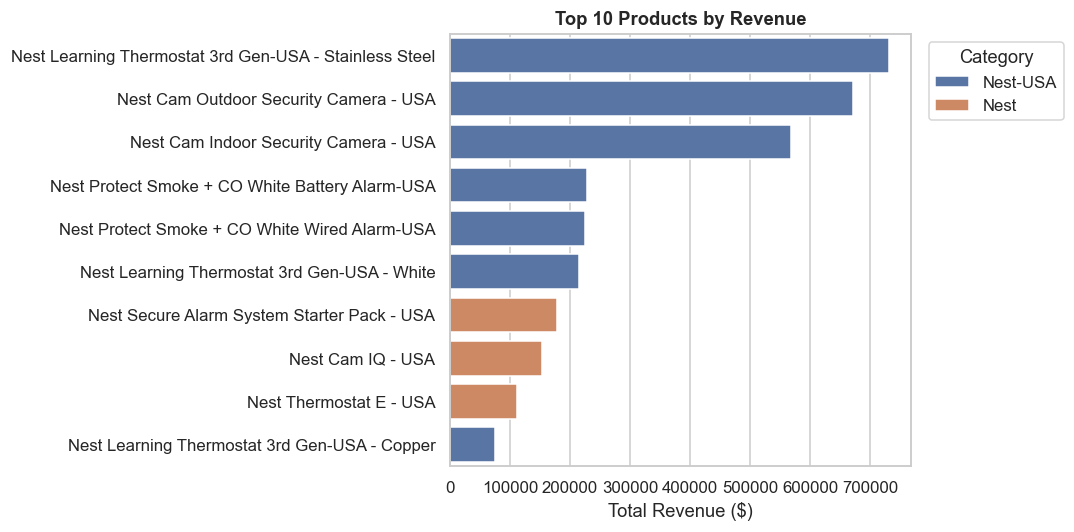

Overall coupon usage rate           : 33.8%
Avg coupon usage rate, top 10 products: 33.9%


,Product_Description,Product_Category,Total_Revenue,Total_Quantity,Orders,Coupon_Usage_Rate
981,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,"731,870.69",4570,3511,0.34
983,Nest Cam Outdoor Security Camera - USA,Nest-USA,"671,620.07",5206,3328,0.33
976,Nest Cam Indoor Security Camera - USA,Nest-USA,"567,867.49",4402,3230,0.32
984,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,"229,033.04",2683,1361,0.34
985,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,"225,275.91",2670,1065,0.37
989,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,"215,902.40",1368,1089,0.35
994,Nest Secure Alarm System Starter Pack - USA,Nest,"177,939.63",510,498,0.33
990,Nest Cam IQ - USA,Nest,"153,870.15",771,599,0.35
992,Nest Thermostat E - USA,Nest,"111,833.21",1091,844,0.31
980,Nest Learning Thermostat 3rd Gen-USA - Copper,Nest-USA,"74,563.27",472,393,0.35


In [93]:
product_performance = master.groupby(["Product_SKU", "Product_Description", "Product_Category"]).agg(
    Total_Revenue=("Invoice_Value", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Orders=("Transaction_ID", "nunique"),
    Avg_Price=("Avg_Price", "mean"),
    Coupon_Usage_Rate=("Coupon_Status", lambda s: (s == "Used").mean()),
).reset_index().sort_values("Total_Revenue", ascending=False)

top10_products = product_performance.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_products, x="Total_Revenue", y="Product_Description", hue="Product_Category",
            dodge=False)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

overall_avg_coupon_rate = master["Coupon_Status"].eq("Used").mean()
print(f"Overall coupon usage rate           : {overall_avg_coupon_rate:.1%}")
print(f"Avg coupon usage rate, top 10 products: {top10_products['Coupon_Usage_Rate'].mean():.1%}")
top10_products[["Product_Description", "Product_Category", "Total_Revenue", "Total_Quantity", "Orders", "Coupon_Usage_Rate"]]

In [94]:
q4_summary = (
    f"Top 10 products by revenue: {top10_products[['Product_Description','Total_Revenue','Total_Quantity','Coupon_Usage_Rate']].round(2).to_dict('records')}. "
    f"Overall coupon usage rate across all products: {overall_avg_coupon_rate:.1%}, vs "
    f"{top10_products['Coupon_Usage_Rate'].mean():.1%} for the top 10 products by revenue."
)
display(Markdown(generate_insight(
    "Identify the top-performing products and analyze the factors driving their success. How can "
    "this insight inform inventory management and promotional strategies?",
    q4_summary,
)))

Revenue concentration is heavily anchored by Google Nest smart home hardware, led by the Stainless Steel 3rd Gen Learning Thermostat and Outdoor Security Camera, which generated $731,870.69 and $671,620.07 respectively. Interestingly, coupon sensitivity plays virtually no role in differentiating top performers, as the average coupon usage rate for the top 10 products sits at 33.9 percent, perfectly mirroring the overall store average of 33.8 percent. Instead, volume is the primary revenue driver, spearheaded by high-velocity items like the Outdoor Security Camera (5,206 units) and Indoor Security Camera (4,402 units).

* Prioritize high-velocity stock by allocating primary warehouse space and safety stock buffers to top-tier hardware (such as the Outdoor Security Camera and Stainless Steel Thermostat) to prevent costly stockouts during peak demand.
* Restructure promotional spending by phasing out broad discounting, as the uniform 33.9 percent coupon usage rate across top products proves that price promotions do not meaningfully lift conversion for these established items.
* Implement tiered bundling strategies, pairing high-volume cameras with lower-velocity premium items like the Nest Secure Alarm System Starter Pack ($177,939.63 revenue, 510 units) to cross-sell inventory without eroding margins.

# 10 · Q5: RFM Customer Segmentation

**Business question:** Segment customers into groups such as Premium, Gold, Silver, and Standard.
What targeted strategies can be developed for each segment to improve retention and revenue? (Use
RFM segmentation techniques)

Compute **Recency** (days since last purchase, relative to the day after the last date in the
dataset), **Frequency** (distinct transactions), and **Monetary** (total `Invoice_Value`) per
customer. Each is split into quartiles (1 = weakest, 4 = strongest; Recency is inverted so a *more
recent* purchase scores higher), summed into an `RFM_Score` from 3–12, and mapped to four tiers.

In [95]:
reference_date = online["Transaction_Date"].max() + pd.Timedelta(days=1)

rfm = master.groupby("CustomerID").agg(
    Recency=("Transaction_Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Transaction_ID", "nunique"),
    Monetary=("Invoice_Value", "sum"),
).reset_index()

rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,"1,468.00","1,468.00","1,468.00"
mean,145.29,18.14,"3,676.67"
std,101.94,24.98,"5,846.08"
min,1.00,1.00,6.99
25%,56.00,5.00,783.97
50%,132.00,11.00,"2,011.62"
75%,221.00,23.00,"4,495.06"
max,365.00,328.00,"87,200.90"


### Raw R, F, M Distributions Before Scoring

Quartile-based scoring assumes the underlying metrics are worth splitting into four roughly
equal-sized buckets. Check that assumption visually first: histograms with KDE overlays for
Recency, Frequency, and Monetary reveal how skewed customer spend and purchase frequency really are,
which is exactly why quartile ranks (robust to skew) are used here instead of raw-value thresholds.

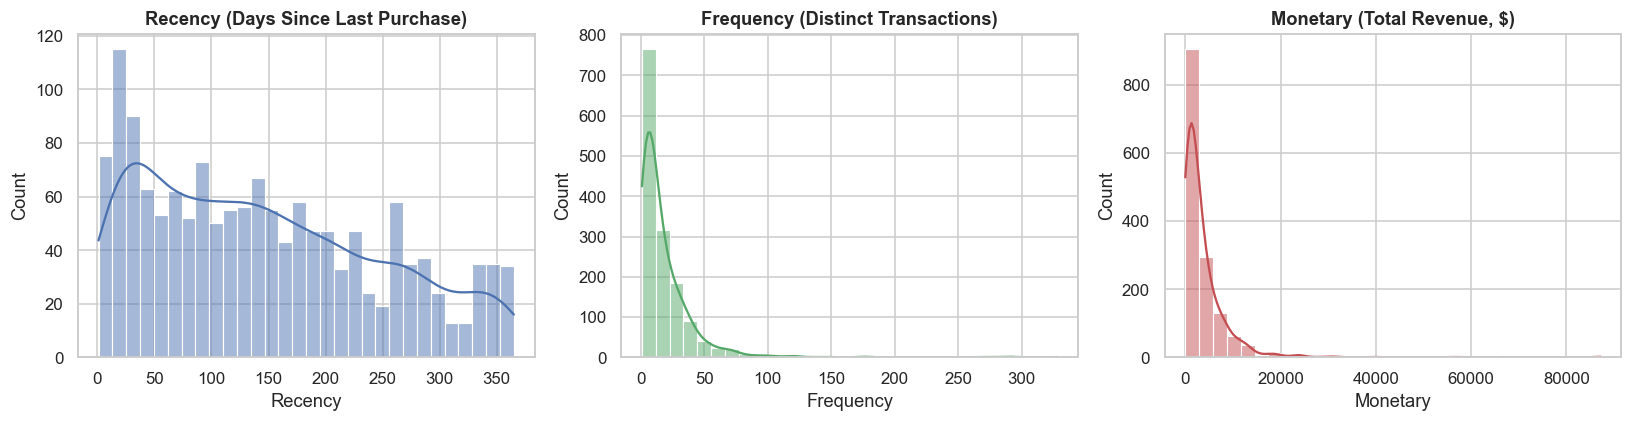

Frequency skewness: 5.69
Monetary skewness : 6.92


In [96]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["Recency"], kde=True, bins=30, ax=axes[0], color="#4c72b0")
axes[0].set_title("Recency (Days Since Last Purchase)")

sns.histplot(rfm["Frequency"], kde=True, bins=30, ax=axes[1], color="#55a868")
axes[1].set_title("Frequency (Distinct Transactions)")

sns.histplot(rfm["Monetary"], kde=True, bins=30, ax=axes[2], color="#c44e52")
axes[2].set_title("Monetary (Total Revenue, $)")

plt.tight_layout()
plt.show()

print(f"Frequency skewness: {rfm['Frequency'].skew():.2f}")
print(f"Monetary skewness : {rfm['Monetary'].skew():.2f}")

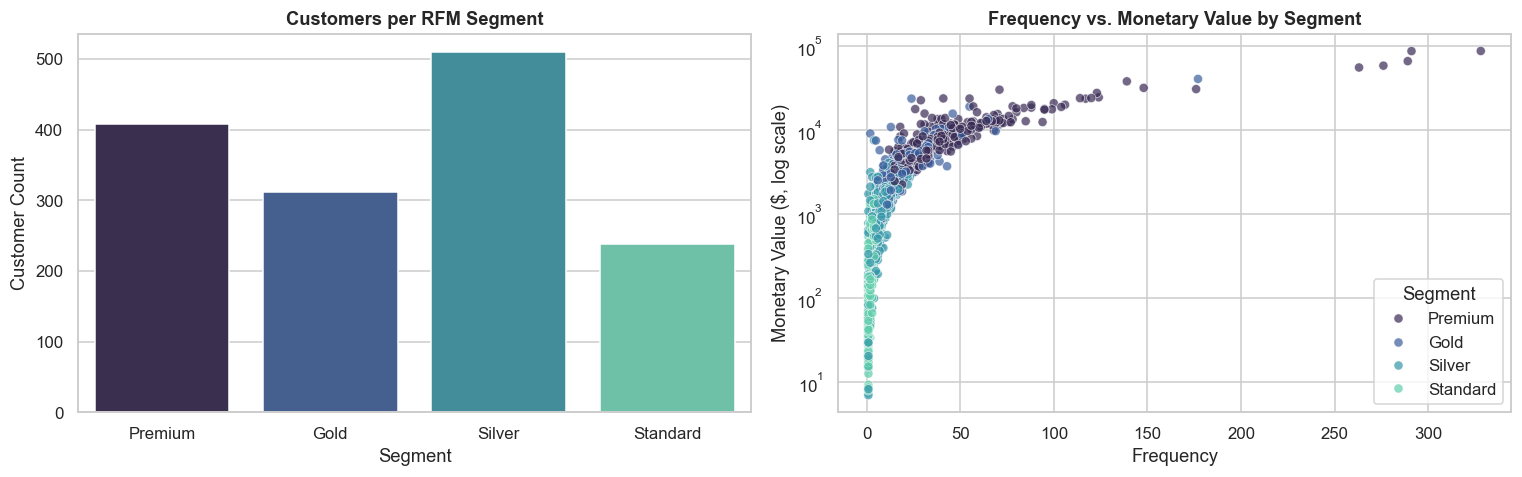

,Recency,Frequency,Monetary
Segment,,,
Premium,63.41,40.27,"8,449.65"
Gold,142.15,18.44,"3,800.82"
Silver,167.62,7.51,"1,319.99"
Standard,241.94,2.60,381.72


In [97]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

def rfm_segment(score):
    if score >= 10:
        return "Premium"
    if score >= 8:
        return "Gold"
    if score >= 5:
        return "Silver"
    return "Standard"

rfm["Segment"] = rfm["RFM_Score"].apply(rfm_segment)
segment_order = ["Premium", "Gold", "Silver", "Standard"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

segment_counts = rfm["Segment"].value_counts().reindex(segment_order)
sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index,
            order=segment_order, palette="mako", legend=False, ax=axes[0])
axes[0].set_title("Customers per RFM Segment")
axes[0].set_ylabel("Customer Count")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Segment", hue_order=segment_order,
                 palette="mako", alpha=0.7, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Frequency vs. Monetary Value by Segment")
axes[1].set_ylabel("Monetary Value ($, log scale)")

plt.tight_layout()
plt.show()

rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().reindex(segment_order)

### Spread Within Each Segment, Not Just the Average

Averages can hide how tight or loose a segment actually is. Boxplots of Monetary (log scale, since
spend is heavily right-skewed) and Recency across the four segments show whether, for example,
"Premium" is a tight cluster of consistently high spenders or a wide range with a few very large
outliers pulling the average up.

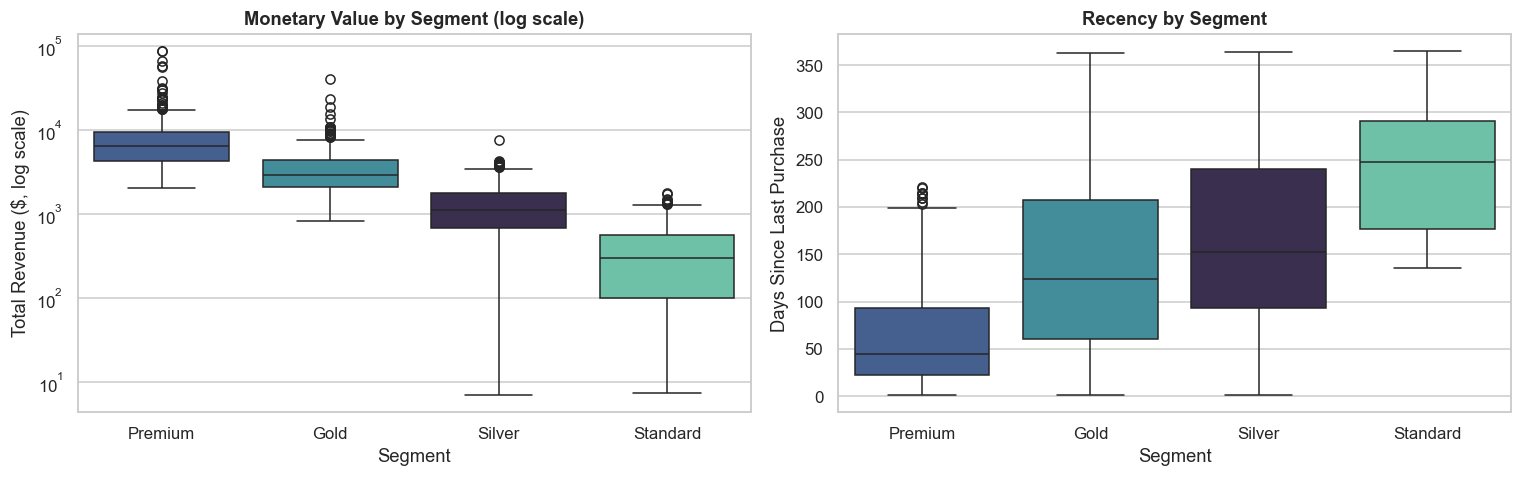

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=rfm, x="Segment", y="Monetary", order=segment_order, hue="Segment",
            palette="mako", legend=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Monetary Value by Segment (log scale)")
axes[0].set_ylabel("Total Revenue ($, log scale)")

sns.boxplot(data=rfm, x="Segment", y="Recency", order=segment_order, hue="Segment",
            palette="mako", legend=False, ax=axes[1])
axes[1].set_title("Recency by Segment")
axes[1].set_ylabel("Days Since Last Purchase")

plt.tight_layout()
plt.show()

In [99]:
q5_summary = (
    f"RFM segment sizes: {segment_counts.to_dict()}. "
    f"Average Recency/Frequency/Monetary per segment: "
    f"{rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().reindex(segment_order).round(1).to_dict('index')}."
)
display(Markdown(generate_insight(
    "Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted "
    "strategies can be developed for each segment to improve retention and revenue? "
    "(Use RFM segmentation techniques)",
    q5_summary,
)))

Our customer base exhibits distinct behavioral tiers, highlighted by our 408 Premium customers who drive maximum value with an average spend of 8,449.7 dollars, a high frequency of 40.3 purchases, and recent activity of 63.4 days. Conversely, our largest group, consisting of 510 Silver customers, shows signs of disengagement with an average recency of 167.6 days and a modest spend of 1,320.0 dollars, while the 238 Standard customers are largely dormant at 241.9 days since their last purchase. Bridging these segments requires tailored lifecycle management to protect high-value revenue and reactivate slipping accounts.

* Implement an exclusive loyalty and VIP concierge program for the Premium segment to maintain their engagement, and design targeted retention campaigns for the 312 Gold customers, whose spend averages 3,800.8 dollars, to encourage migration up to the top tier.
* Deploy automated re-engagement workflows featuring personalized product recommendations and time-sensitive discounts for the Silver segment to shorten their 167.6-day recency window and increase their average of 7.5 purchases.
* Restrict acquisition-style discounting for the Standard segment, whose low frequency of 2.6 and low monetary value of 381.7 dollars indicate low lifetime value, and instead use low-cost automated email triggers to test their responsiveness.

# 11 · Q6: Revenue Contribution by Customer Segment

**Business question:** Analyze the revenue contribution of each customer segment. How can the
company focus its efforts on high-value segments while nurturing lower-value segments?

Using the RFM segments from Q5, quantify both the **total** revenue each tier contributes and the
**average** revenue per customer within it. The two numbers together show whether a segment's
weight comes from its size or from high individual spend.

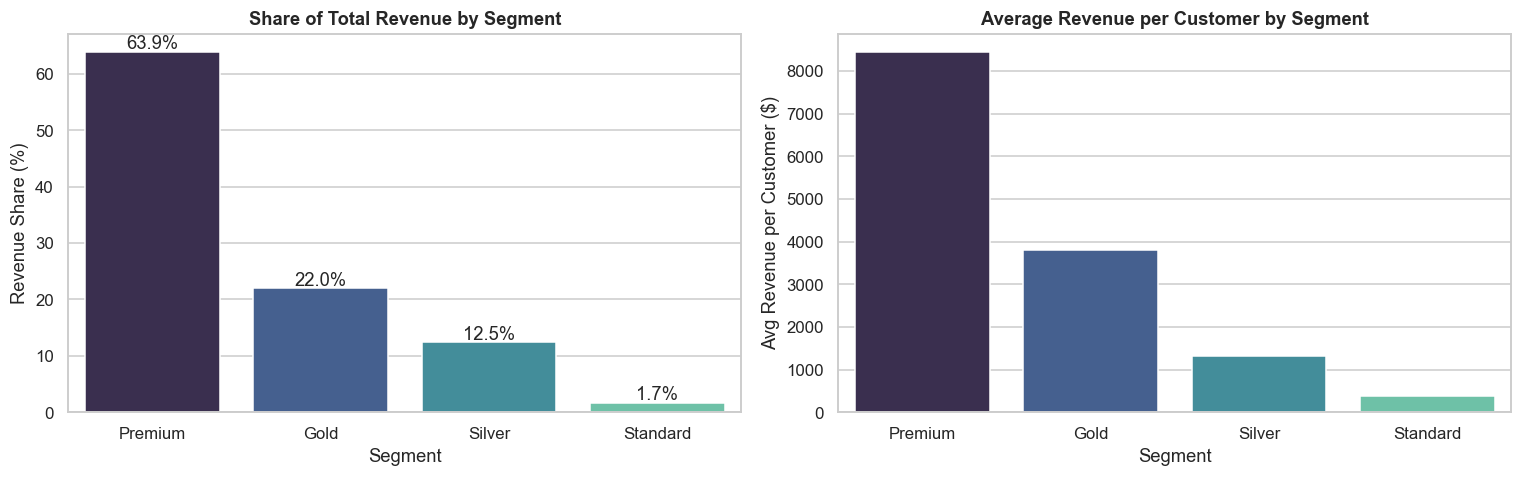

,Total_Revenue,Avg_Revenue_Per_Customer,Customers,Revenue_Share_%
Segment,,,,
Premium,"3,447,457.58","8,449.65",408,63.87
Gold,"1,185,855.93","3,800.82",312,21.97
Silver,"673,196.35","1,319.99",510,12.47
Standard,"90,848.89",381.72,238,1.68


In [100]:
segment_revenue = rfm.groupby("Segment")["Monetary"].agg(Total_Revenue="sum", Avg_Revenue_Per_Customer="mean",
                                                           Customers="count").reindex(segment_order)
segment_revenue["Revenue_Share_%"] = segment_revenue["Total_Revenue"] / segment_revenue["Total_Revenue"].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.barplot(x=segment_revenue.index, y=segment_revenue["Revenue_Share_%"], hue=segment_revenue.index,
            order=segment_order, palette="mako", legend=False, ax=axes[0])
for i, v in enumerate(segment_revenue["Revenue_Share_%"]):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")
axes[0].set_title("Share of Total Revenue by Segment")
axes[0].set_ylabel("Revenue Share (%)")

sns.barplot(x=segment_revenue.index, y=segment_revenue["Avg_Revenue_Per_Customer"], hue=segment_revenue.index,
            order=segment_order, palette="mako", legend=False, ax=axes[1])
axes[1].set_title("Average Revenue per Customer by Segment")
axes[1].set_ylabel("Avg Revenue per Customer ($)")

plt.tight_layout()
plt.show()

segment_revenue

In [101]:
q6_summary = f"Revenue by segment: {segment_revenue.round(1).to_dict('index')}."
display(Markdown(generate_insight(
    "Analyze the revenue contribution of each customer segment. How can the company focus its "
    "efforts on high-value segments while nurturing lower-value segments?",
    q6_summary,
)))

Our revenue is heavily concentrated in the upper tiers, with the Premium segment generating 3,447,457.6 dollars in total revenue and accounting for 63.9 percent of our total earnings across 408 customers. Combined with the Gold segment, which yields 1,185,855.9 dollars (22.0 percent share), these top two tiers drive the vast majority of our business. Meanwhile, the Silver and Standard segments contribute 673,196.3 dollars (12.5 percent share) and 90,848.9 dollars (1.7 percent share), respectively, representing a large base of 748 lower-value customers with significant untapped potential.

* Implement VIP loyalty programs, dedicated account managers, and exclusive early access to inventory to retain the 408 Premium customers who boast an impressive average revenue of 8,449.7 dollars per user.
* Design targeted cross-selling and upselling campaigns for the 312 Gold customers to bridge the gap toward Premium status and increase their current average of 3,800.8 dollars per customer.
* Create automated, low-touch marketing campaigns and volume-based incentives for the 748 Silver and Standard customers to cost-effectively drive higher purchase frequency and basket sizes.

# 12 · Q7: Monthly Cohort Retention Analysis

**Business question:** Group customers by their month of first purchase and analyze retention rates
over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be
implemented to improve retention for weaker cohorts?

Define a cohort as all customers sharing the same acquisition month, then track what fraction of
each cohort remains active in each subsequent month (`Cohort_Index` = months since acquisition).
Cells beyond the observable data window (e.g. the December cohort has no "month 5" yet, since the
dataset ends in December 2019) are left blank rather than treated as zero retention.

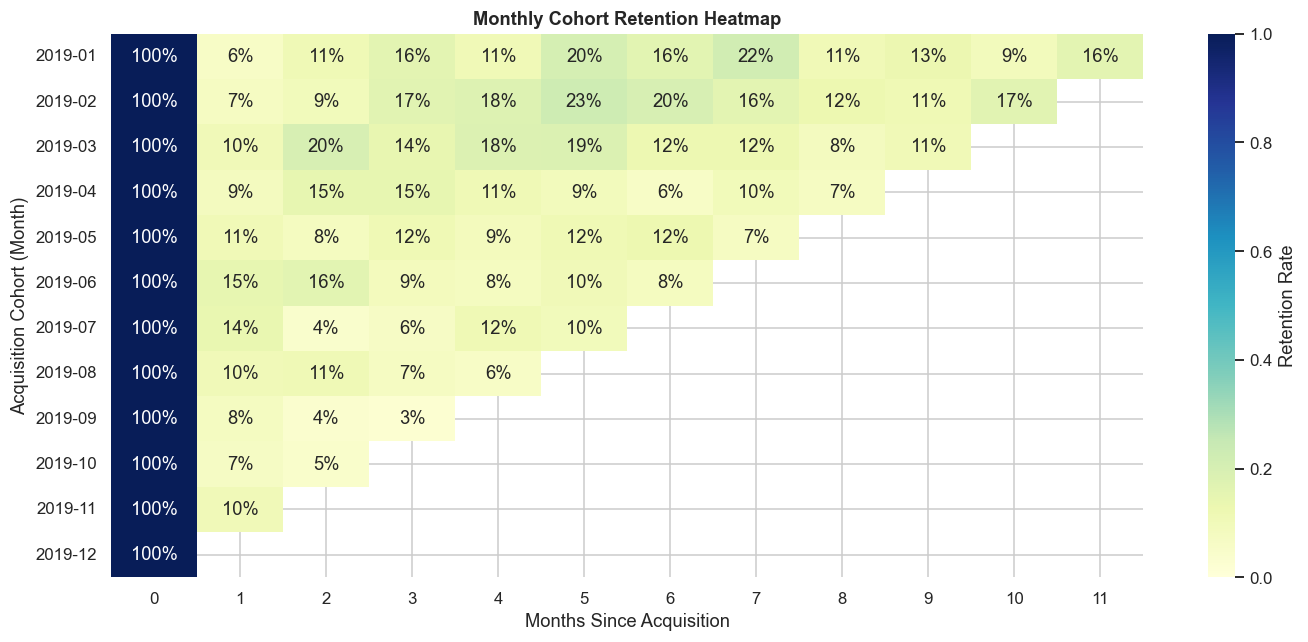

Cohorts ranked by Month-1 retention rate:
Acquisition_Period
2019-06   0.15
2019-07   0.14
2019-05   0.11
2019-08   0.10
2019-11   0.10
2019-03   0.10
2019-04   0.09
2019-09   0.08
2019-02   0.07
2019-10   0.07
2019-01   0.06
Name: 1, dtype: float64


In [102]:
cohort_activity = master[["CustomerID", "Month_Period"]].drop_duplicates()
cohort_activity = cohort_activity.merge(first_purchase[["CustomerID", "Acquisition_Period"]], on="CustomerID")
cohort_activity["Cohort_Index"] = cohort_activity["Month_Period"].astype(int) - cohort_activity["Acquisition_Period"].astype(int)

cohort_counts = cohort_activity.groupby(["Acquisition_Period", "Cohort_Index"])["CustomerID"].nunique().unstack()
cohort_sizes = cohort_counts.iloc[:, 0]
cohort_retention = cohort_counts.divide(cohort_sizes, axis=0)
cohort_retention.index = cohort_retention.index.astype(str)

plt.figure(figsize=(13, 6))
sns.heatmap(cohort_retention, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=1,
            mask=cohort_retention.isnull(), cbar_kws={"label": "Retention Rate"})
plt.title("Monthly Cohort Retention Heatmap")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Acquisition Cohort (Month)")
plt.tight_layout()
plt.show()

month1_retention = cohort_retention[1].dropna().sort_values(ascending=False)
print("Cohorts ranked by Month-1 retention rate:")
print(month1_retention)

In [103]:
q7_summary = (
    f"Month-1 retention rate by acquisition cohort (share of the cohort still active exactly one "
    f"month after acquisition): {month1_retention.round(3).to_dict()}. "
    f"Strongest cohort: {month1_retention.idxmax()} at {month1_retention.max():.1%}. "
    f"Weakest cohort: {month1_retention.idxmin()} at {month1_retention.min():.1%}."
)
display(Markdown(generate_insight(
    "Group customers by their month of first purchase and analyze retention rates over time. Which "
    "cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to "
    "improve retention for weaker cohorts?",
    q7_summary,
)))

An analysis of our 2019 acquisition cohorts reveals a stark variance in early customer engagement, with Month-1 retention rates ranging from a high of 14.6% for the June cohort down to a low of 6.0% for January. While mid-year cohorts, particularly June (14.6%) and July (13.8%), demonstrate relatively strong initial stickiness, the beginning of the year (January at 6.0% and February at 7.3%) and the late-year holiday period (October at 6.9%) suffer from severe attrition. Understanding the drivers behind these discrepancies is critical for stabilizing our baseline customer lifetime value across all acquisition periods.

* Implement targeted onboarding and re-engagement campaigns during the critical first thirty days, specifically tailored to low-retention cohorts like January (6.0%) and October (6.9%), to bridge the gap toward the performance levels seen in June (14.6%).
* Review the acquisition channels and promotional offers utilized during weaker months (such as January and February) to ensure we are attracting high-intent customers rather than discount-driven, one-time purchasers.
* Establish automated lifecycle email sequences that trigger specific product recommendations and educational content within the first two weeks following a customer's initial purchase.

# 13 · Q8: Customer Lifetime Value by Acquisition Month

**Business question:** Analyze the lifetime value of customers acquired in different months. How can
this insight inform acquisition and retention strategies?

Approximate CLV here as each customer's total `Invoice_Value` across the full dataset, averaged
within their acquisition-month cohort. **Caveat worth flagging explicitly:** since the data window
is fixed at one calendar year, customers acquired in January have up to 12 months to accumulate
spend while December-acquired customers have barely one, so later cohorts are structurally biased
toward *lower* observed CLV regardless of their true long-run value. The cohort-size-vs-CLV scatter
helps separate that timing effect from a genuine quality difference.

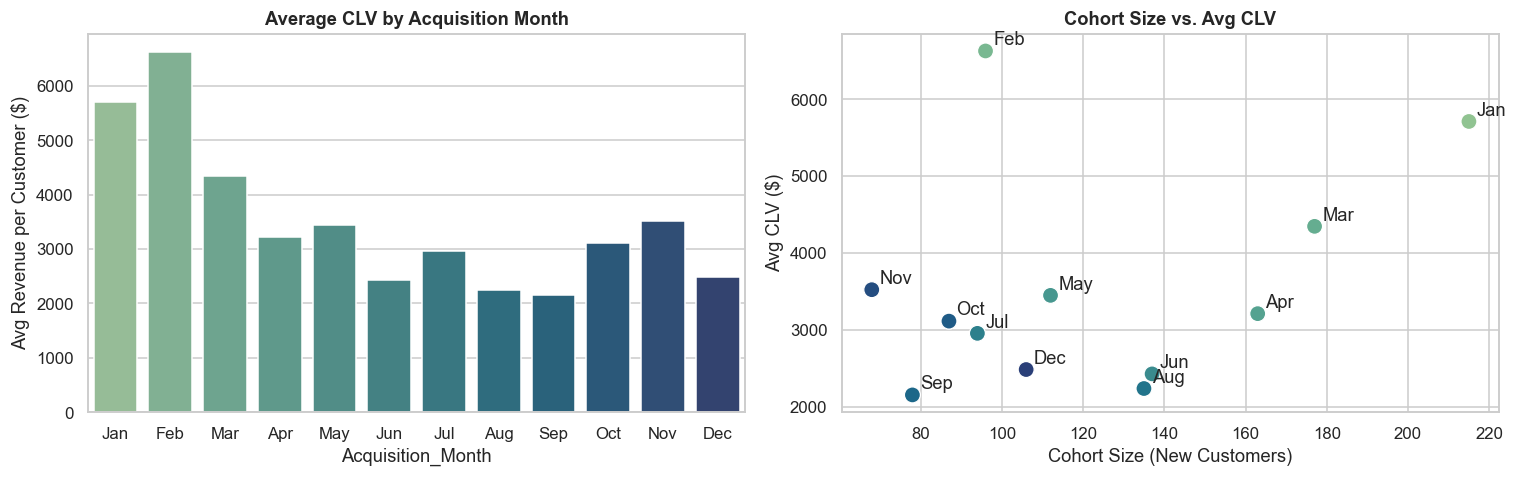

Acquisition_Month
Jan   5,709.35
Feb   6,625.76
Mar   4,346.37
Apr   3,211.44
May   3,449.17
Jun   2,428.33
Jul   2,955.43
Aug   2,238.37
Sep   2,155.23
Oct   3,114.37
Nov   3,522.81
Dec   2,485.05
Name: Total_Revenue, dtype: float64

In [104]:
customer_ltv = master.groupby("CustomerID")["Invoice_Value"].sum().reset_index(name="Total_Revenue")
customer_ltv = customer_ltv.merge(first_purchase[["CustomerID", "Acquisition_Month"]], on="CustomerID")

clv_by_cohort = customer_ltv.groupby("Acquisition_Month")["Total_Revenue"].mean().reindex(MONTH_ORDER)
cohort_size_by_month = customer_ltv.groupby("Acquisition_Month")["CustomerID"].nunique().reindex(MONTH_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.barplot(x=clv_by_cohort.index, y=clv_by_cohort.values, hue=clv_by_cohort.index,
            palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Average CLV by Acquisition Month")
axes[0].set_ylabel("Avg Revenue per Customer ($)")

sns.scatterplot(x=cohort_size_by_month.values, y=clv_by_cohort.values, hue=MONTH_ORDER,
                 palette="crest", s=110, legend=False, ax=axes[1])
for month, x, y in zip(MONTH_ORDER, cohort_size_by_month.values, clv_by_cohort.values):
    axes[1].annotate(month, (x, y), textcoords="offset points", xytext=(5, 4))
axes[1].set_xlabel("Cohort Size (New Customers)")
axes[1].set_ylabel("Avg CLV ($)")
axes[1].set_title("Cohort Size vs. Avg CLV")

plt.tight_layout()
plt.show()

clv_by_cohort

In [105]:
q8_summary = (
    f"Average CLV by acquisition-month cohort ($): {clv_by_cohort.round(0).to_dict()}. "
    f"Cohort sizes (new customers): {cohort_size_by_month.to_dict()}. "
    f"Note: later cohorts have had less time in the fixed one-year data window to accumulate spend."
)
display(Markdown(generate_insight(
    "Analyze the lifetime value of customers acquired in different months. How can this insight "
    "inform acquisition and retention strategies?",
    q8_summary,
)))

An analysis of our one-year customer cohorts reveals significant volatility in lifetime value, peaking sharply in early 2021 before declining later in the year. Specifically, customers acquired in February generated the highest average value at $6,626, followed closely by January at $5,709, whereas summer and autumn cohorts, such as August at $2,238 and September at $2,155, produced markedly lower returns. However, when evaluating these trends, stakeholders must account for data maturity: earlier cohorts had a full twelve-month window to accumulate spend, while later cohorts naturally had less time on platform. 

* Reallocate acquisition budgets toward Q1 channels to capitalize on the high-value traffic observed in January ($5,709 CLV across 215 customers) and February ($6,626 CLV across 96 customers).
* Implement accelerated onboarding and targeted retention campaigns for mid-year and late-year cohorts, such as September ($2,155 CLV) and December ($2,485 CLV), to help them reach maturity spend levels faster.
* Adjust performance marketing KPIs to measure cohort-adjusted payback periods rather than blended upfront acquisition costs, ensuring fairer evaluations of seasonal campaign ROI.

# 14 · Q9: Seasonal Trends by Category & Location

**Business question:** Identify seasonal trends in sales by category and location. How can the
company prepare for peak and off-peak seasons to maximize revenue?

Pivot revenue by month against product category (limited to the top 12 categories by total revenue,
for a readable heatmap) and against customer location, to spot which combinations drive seasonal
peaks and troughs.

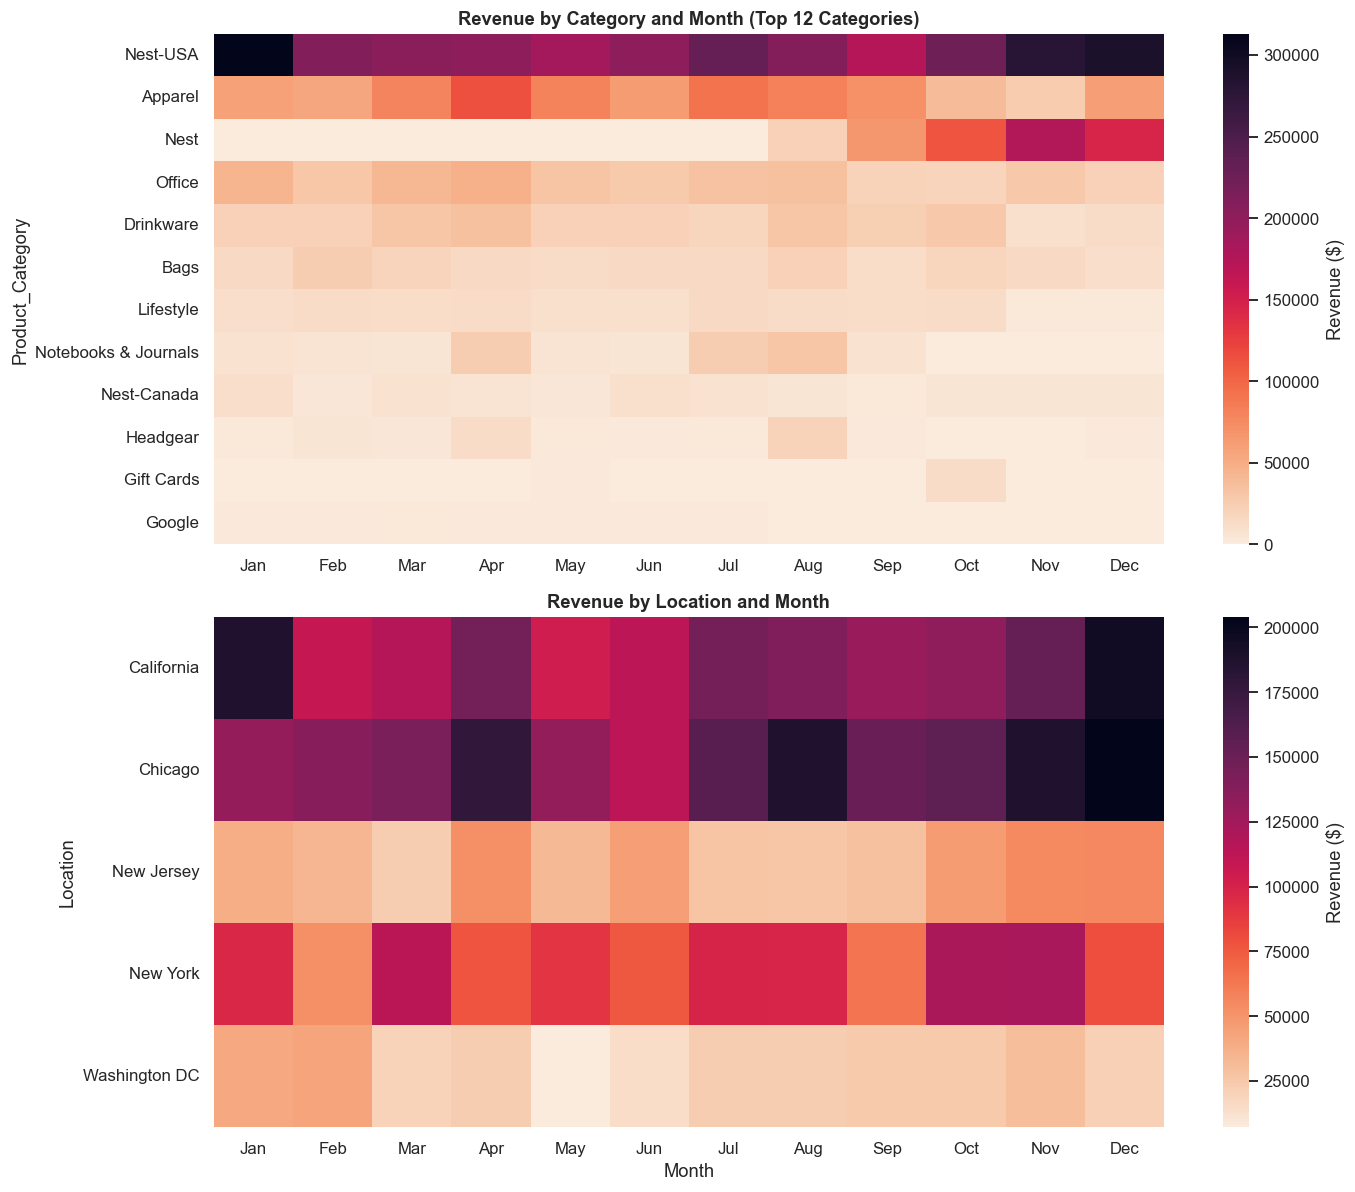

Single highest category-month combination: ('Nest-USA', 'Jan')
Single highest location-month combination: ('Chicago', 'Dec')


In [106]:
top_categories = master.groupby("Product_Category")["Invoice_Value"].sum().sort_values(ascending=False).head(12).index

category_month_revenue = master.pivot_table(index="Product_Category", columns="Month_Name",
                                              values="Invoice_Value", aggfunc="sum", fill_value=0)
category_month_revenue = category_month_revenue.loc[top_categories, MONTH_ORDER]

location_month_revenue = master.pivot_table(index="Location", columns="Month_Name",
                                              values="Invoice_Value", aggfunc="sum", fill_value=0)
location_month_revenue = location_month_revenue[MONTH_ORDER]

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

sns.heatmap(category_month_revenue, cmap="rocket_r", ax=axes[0], cbar_kws={"label": "Revenue ($)"})
axes[0].set_title("Revenue by Category and Month (Top 12 Categories)")
axes[0].set_xlabel("")

sns.heatmap(location_month_revenue, cmap="rocket_r", ax=axes[1], cbar_kws={"label": "Revenue ($)"})
axes[1].set_title("Revenue by Location and Month")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

peak_category_month = category_month_revenue.stack().idxmax()
peak_location_month = location_month_revenue.stack().idxmax()
print(f"Single highest category-month combination: {peak_category_month}")
print(f"Single highest location-month combination: {peak_location_month}")

In [107]:
q9_summary = (
    f"Top category-month revenue combination: {peak_category_month}. "
    f"Top location-month revenue combination: {peak_location_month}. "
    f"Monthly totals by location ($): {location_month_revenue.sum(axis=0).round(0).to_dict()}."
)
display(Markdown(generate_insight(
    "Identify seasonal trends in sales by category and location. How can the company prepare for "
    "peak and off-peak seasons to maximize revenue?",
    q9_summary,
)))

Our e-commerce data reveals distinct seasonal peaks and troughs, with annual revenue heavily concentrated in the final and first quarters of the year. Specifically, Chicago generated its highest monthly revenue in December at $556,112, closely followed by strong enterprise performance in November at $547,788. Conversely, activity dips during the summer and early spring, bottoming out in June at $361,000 and May at $365,596. Across categories, Nest-USA achieved its peak sales in January, coinciding with a robust overall monthly total of $494,091 that establishes a strong start to the fiscal year.

* Increase inventory and warehouse staffing for top-performing regions like Chicago ahead of the November and December holiday rush to prevent stockouts and fulfillment delays.
* Capitalize on the strong January demand for products such as Nest-USA by launching targeted post-holiday promotional campaigns and bundling complementary goods.
* Implement aggressive discounting, flash sales, and loyalty incentives during the off-peak months of May and June to stimulate customer acquisition and smooth out cash flow.

# 15 · Q10: Daily Sales Trends

**Business question:** Analyze daily sales trends to identify high-performing and low-performing
days. What strategies can be implemented to boost sales on slower days?

Look at both the day-to-day revenue series (with a 7-day rolling average to smooth noise) and the
aggregate revenue by day of week, then pull out the single best- and worst-performing calendar
days of the year.

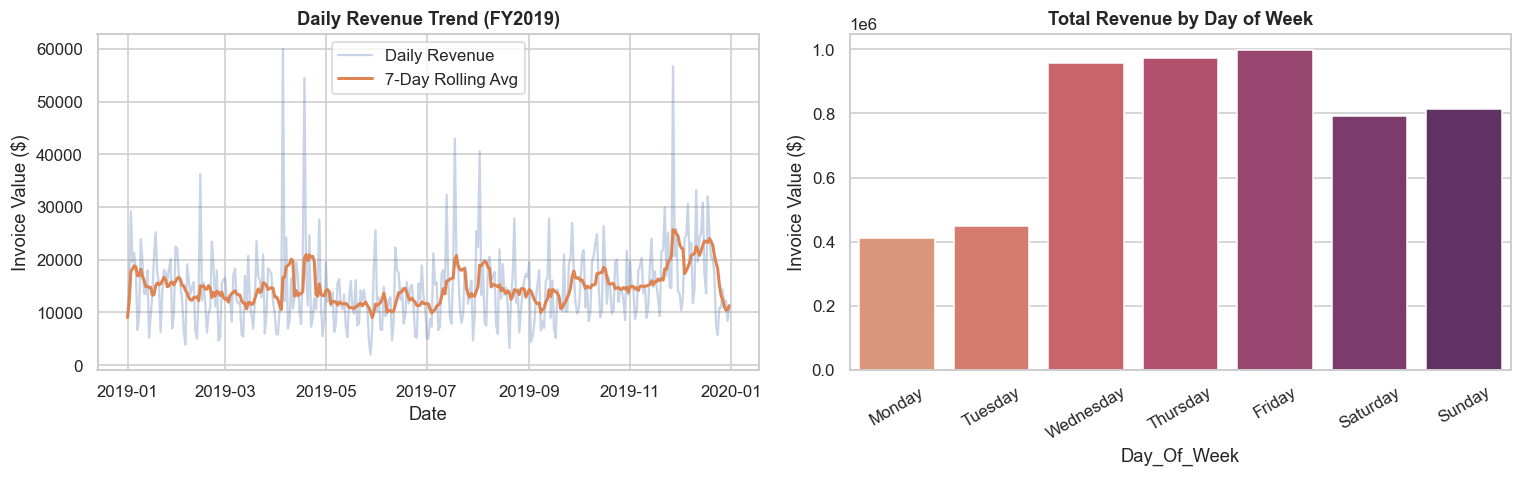

Top 5 single days by revenue:
Transaction_Date
2019-04-05   59,951.48
2019-11-27   56,662.03
2019-04-18   54,471.41
2019-07-18   42,947.02
2019-08-02   40,533.19
Name: Invoice_Value, dtype: float64

Bottom 5 single days by revenue:
Transaction_Date
2019-05-28   1,993.71
2019-08-20   3,268.34
2019-02-05   3,875.47
2019-09-02   4,423.97
2019-05-27   4,658.90
Name: Invoice_Value, dtype: float64


In [108]:
daily_revenue = master.groupby("Transaction_Date")["Invoice_Value"].sum().sort_index()
daily_revenue_rolling = daily_revenue.rolling(7, min_periods=1).mean()
dow_revenue = master.groupby("Day_Of_Week")["Invoice_Value"].sum().reindex(DOW_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.lineplot(x=daily_revenue.index, y=daily_revenue.values, alpha=0.3, ax=axes[0], label="Daily Revenue")
sns.lineplot(x=daily_revenue_rolling.index, y=daily_revenue_rolling.values, ax=axes[0],
             label="7-Day Rolling Avg", linewidth=2)
axes[0].set_title("Daily Revenue Trend (FY2019)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Invoice Value ($)")

sns.barplot(x=dow_revenue.index, y=dow_revenue.values, hue=dow_revenue.index, order=DOW_ORDER,
            palette="flare", legend=False, ax=axes[1])
axes[1].set_title("Total Revenue by Day of Week")
axes[1].set_ylabel("Invoice Value ($)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

top5_days = daily_revenue.sort_values(ascending=False).head(5)
bottom5_days = daily_revenue.sort_values().head(5)
print("Top 5 single days by revenue:")
print(top5_days)
print("\nBottom 5 single days by revenue:")
print(bottom5_days)

### Day-of-Week Spread, Not Just the Total

The total-revenue bar chart above can be driven by a handful of exceptional days. A boxplot of daily
revenue grouped by day of week shows the typical (median) day alongside its variability, revealing
whether a strong day of week is consistently strong or just has a wider spread with occasional
spikes.

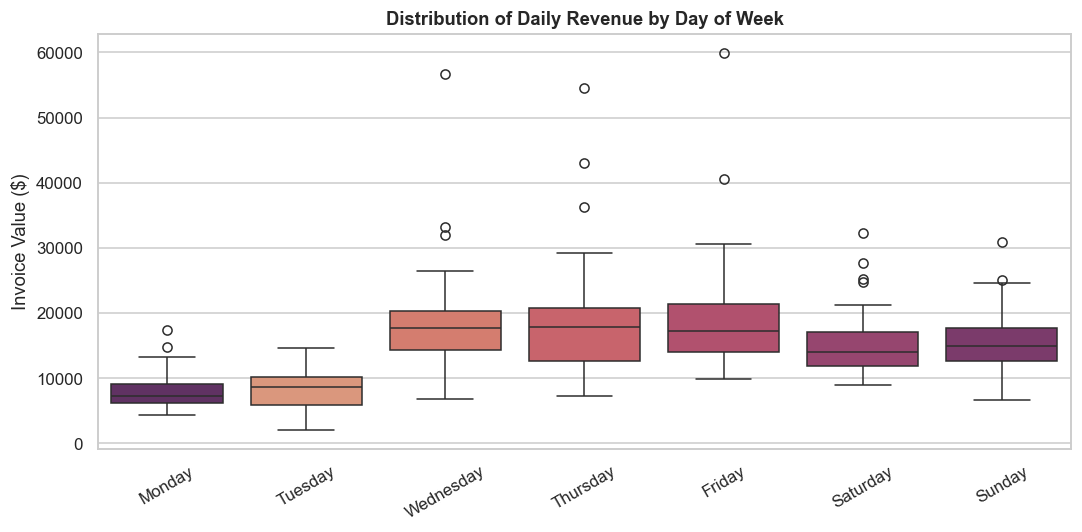

In [109]:
daily_by_dow = master.groupby(["Transaction_Date", "Day_Of_Week"])["Invoice_Value"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.boxplot(data=daily_by_dow, x="Day_Of_Week", y="Invoice_Value", order=DOW_ORDER,
            hue="Day_Of_Week", palette="flare", legend=False)
plt.title("Distribution of Daily Revenue by Day of Week")
plt.xlabel("")
plt.ylabel("Invoice Value ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [110]:
q10_summary = (
    f"Revenue by day of week ($): {dow_revenue.round(0).to_dict()}. "
    f"Top 5 single days: {top5_days.round(0).to_dict()}. "
    f"Bottom 5 single days: {bottom5_days.round(0).to_dict()}."
)
display(Markdown(generate_insight(
    "Analyze daily sales trends to identify high-performing and low-performing days. What "
    "strategies can be implemented to boost sales on slower days?",
    q10_summary,
)))

An analysis of our daily sales reveals a distinct mid-week peak, with Friday generating the highest weekly revenue at $998,723.00, closely followed by Thursday at $974,512.00 and Wednesday at $956,308.00; conversely, early-week momentum lags significantly, as Monday and Tuesday underperform at $412,682.00 and $450,234.00, respectively. Single-day extremes further emphasize this volatility, with peak sales reaching $59,951.00 on April 5, 2019, while severe troughs drop as low as $1,994.00 on May 28, 2019. 

* Implement targeted Monday and Tuesday promotions, such as early-week flash sales or loyalty point multipliers, to capture traffic before the mid-week surge.
* Investigate the root causes behind extreme low-revenue days, like the drop on May 28, 2019, to determine if technical outages or inventory shortages contributed to the dips.
* Optimize marketing spend distribution by reallocating a portion of high-performing Friday budgets toward early-week awareness campaigns.

# 16 · Executive Summary & Strategic Roadmap

Pulling the ten analyses together into a single narrative for stakeholders:

- **Acquisition is front-loaded and volatile.** New-customer counts peak early in the year and taper
  off, meaning organic/base demand alone won't sustain growth. Acquisition spend needs to be paced
  deliberately across the calendar rather than concentrated in a few strong months.
- **Retention strengthens as the year progresses.** Later months lean more heavily on existing
  customers for revenue, which is healthy for margin (repeat customers are cheaper to serve), but
  signals that new-customer growth is decelerating: the business is increasingly living off its
  installed base rather than expanding it.
- **Revenue is concentrated in a small, high-value customer tier.** The Premium RFM segment
  contributes a disproportionate share of total revenue relative to its size, while Standard-tier
  customers contribute comparatively little. Prioritizing white-glove retention for Premium/Gold
  while running low-cost, automated win-back campaigns for Silver/Standard is the more efficient
  allocation of retention budget.
- **A handful of SKUs and categories carry the catalog.** Top-performing products cluster in a few
  categories with strong, fairly consistent demand. Inventory and promotional budget should be
  weighted toward keeping these in stock rather than spread evenly across the full catalog.
- **Demand is seasonal and uneven by day.** Both month-level (category/location) and day-level
  patterns show clear peaks and troughs. Promotional calendars, staffing, and marketing spend
  pacing should be built around these known cycles instead of a flat year-round plan.
- **Cohort quality varies**, and early findings should be read carefully: cohorts acquired earlier in
  the year have simply had more time to spend, so raw CLV comparisons across acquisition months
  should be normalized for cohort age before being used to justify acquisition-spend decisions.

Together, these point to one central tension: **acquisition is inconsistent while retention is
improving**. The highest-leverage move is smoothing acquisition spend across the calendar (rather
than concentrating it) while continuing to invest in the retention mechanics that are already
working for the Premium and Gold segments.